In [1]:
# This is boilerplate code to correctly setup the settings to for notebook.
import os, sys
for root, dirs, files in os.walk(os.getcwd()):
    # print(root)

    if "pion-argon-xs-analysis" in root.split("/"):
        pypath = root.split("pion-argon-xs-analysis")[0] + "/pion-argon-xs-analysis/analysis"
        print(pypath)
        break

sys.path.insert(0, pypath)

from python.analysis.NotebookUtils import init_notebook
%init_notebook

/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis
/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis
env: PYTHONPATH=/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis


In [3]:
from python.analysis import cross_section, Application, Master, Plots
from python.analysis.MaCh3FitOutput import MaCh3FitOutput
from apps import cex_cross_section
import numpy as np
import awkward as ak
import scipy.stats as stats


cross_section.PlotStyler(dark=True)

In [5]:
config = "work/analysis_new_selection/analysis_config_new_selection.json"
args = Application.ApplicationArguments.ResolveConfig(Master.LoadConfiguration(config))
ais = {k : cross_section.LoadObject(v) for k, v in args.analysis_input.items() if "mc" in k}

In [6]:
postfit_results = MaCh3FitOutput("/home/bhuller/mach3_dune/MaCh3_DUNE/Test.root", args.process_definitions, args.energy_slices)

book = Plots.PlotBook("xs_extract", True, None)


pdf xs_extract.pdf has been opened


In [7]:
from matplotlib.patches import Rectangle

def HighlightCells(ax, mask):
    rows, cols = np.where(mask)

    for row, col in zip(rows, cols):
        ax.add_patch(
            Rectangle(
                (col - 0.5, row - 0.5),
                1,
                1,
                fill=False,
                edgecolor="red",
                linewidth=2,
            )
        )
    return

def PlotMatrix(matrix : np.ndarray, highlight : np.ndarray = None, title : str = None):
    fig, ax = Plots.plt.subplots()

    im = ax.imshow(matrix)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("mean value")

    ticks = ["Overflow"] + list(args.energy_slices.num) + ["Underflow"]
    Plots.plt.grid(False)
    Plots.plt.xticks(range(len(ticks)), ticks)
    Plots.plt.yticks(range(len(ticks)), ticks)
    Plots.plt.title(title)

    if highlight is not None:
        HighlightCells(ax, highlight)
    return

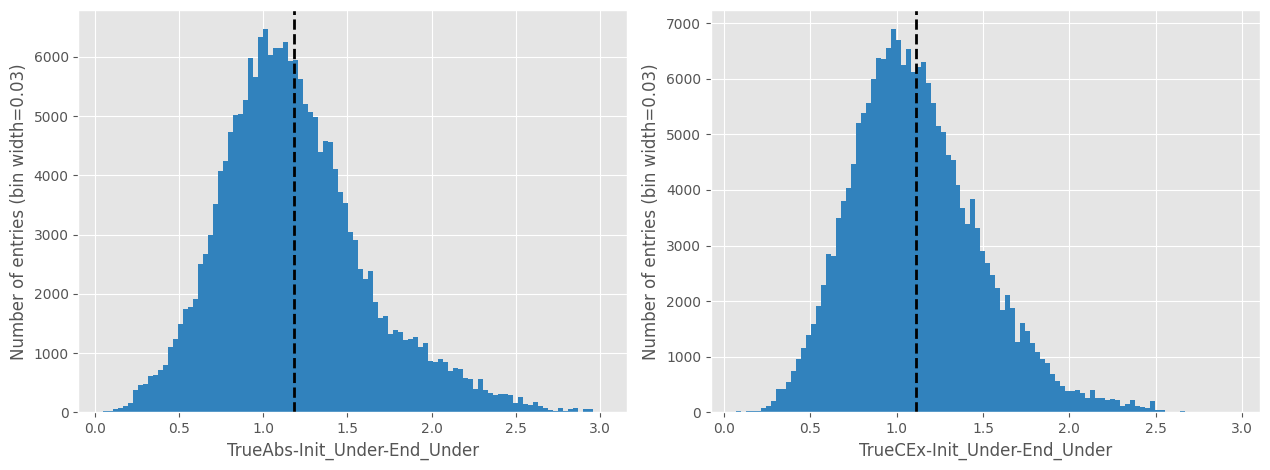

In [8]:
for i in Plots.MultiPlot(2):
    k, v = list(postfit_results.posteriors.items())[i]
    Plots.PlotHist(v, xlabel = k, newFigure=False)
    Plots.plt.axvline(np.mean(v), color = "k", linewidth=2, linestyle = "--")
book.Save()

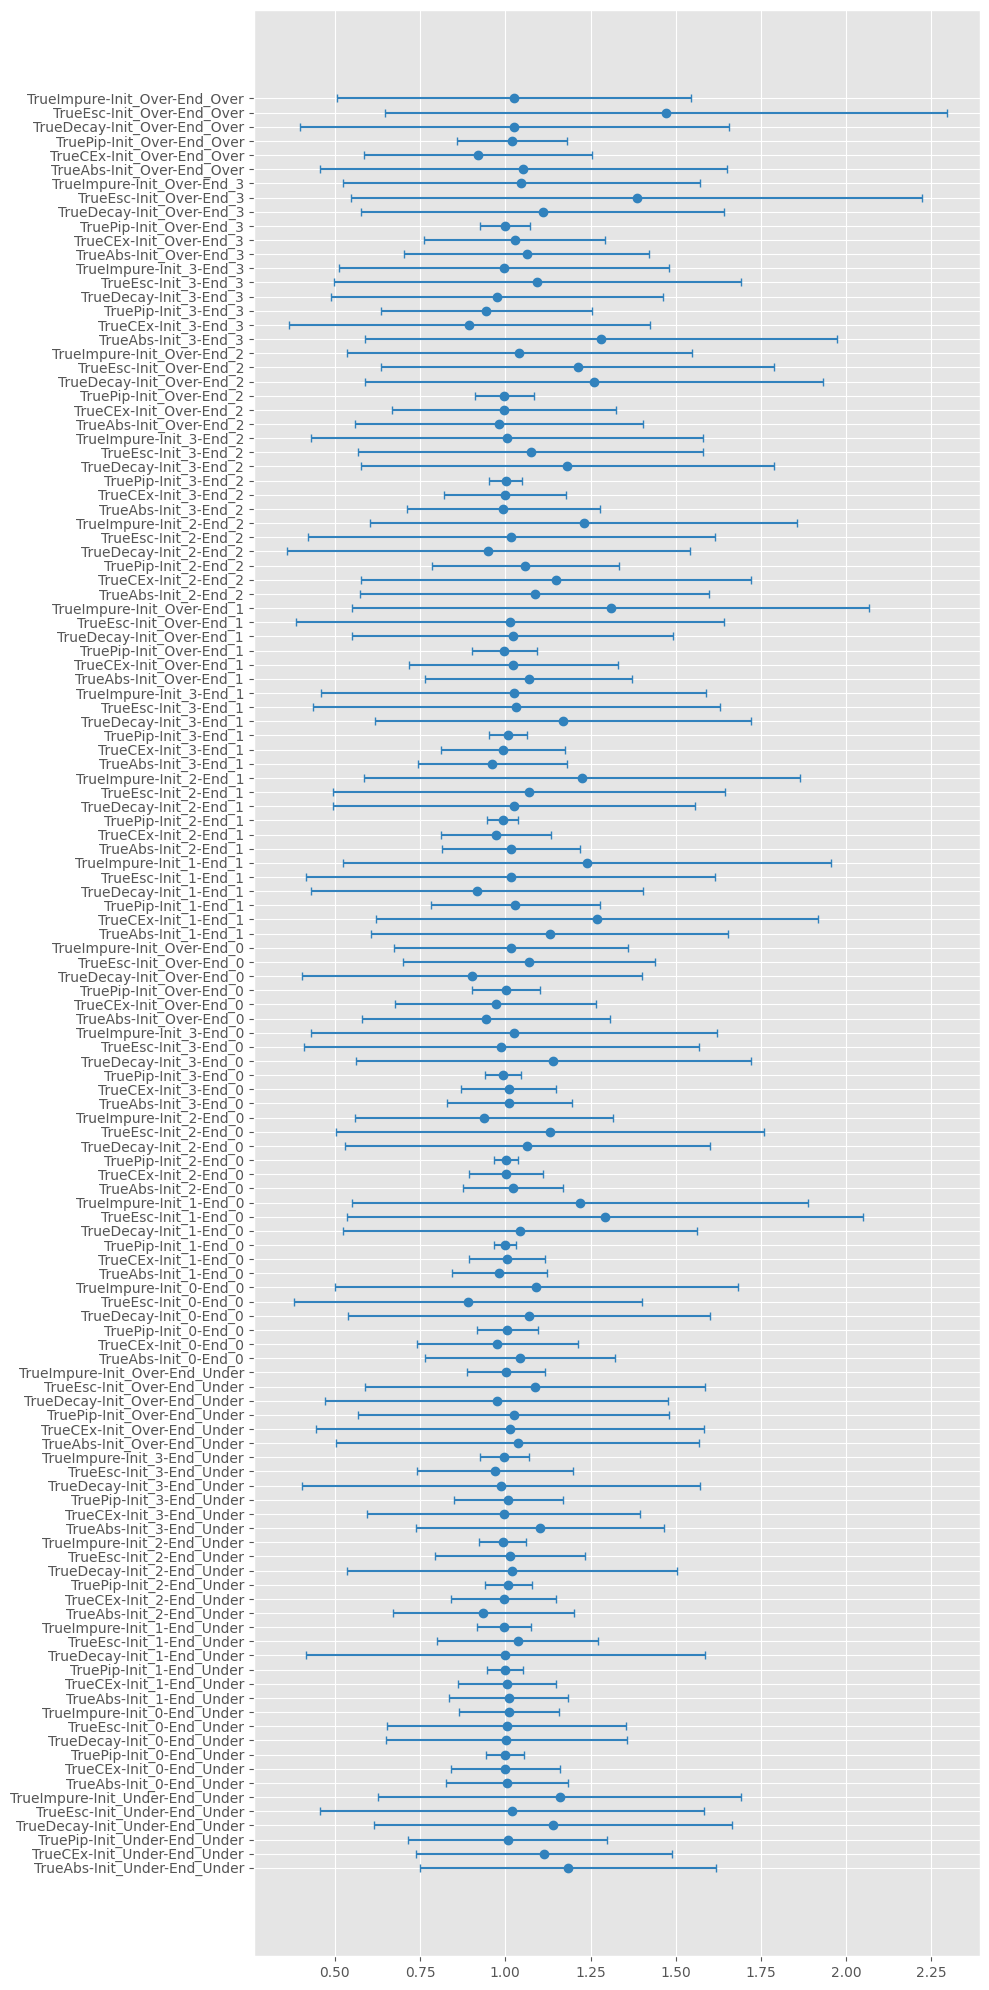

In [9]:
mean_params = {k : np.mean(v) for k, v in postfit_results.posteriors.items()}
# stderr_params = {k : abs(np.abs(stats.t.interval(0.68, df = len(v)-1, loc=np.mean(v), scale=np.std(v, ddof=1) / np.sqrt(len(v)))) - np.mean(v)) for k, v in postfit_results.posteriors.items()}

stderr_params = {k : np.std(v, ddof=1) for k, v in postfit_results.posteriors.items()}


Plots.plt.figure(figsize=[10, 20])
Plots.Plot(list(mean_params.values()), range(len(mean_params)), xerr=np.array(list(stderr_params.values())).T, newFigure=False, marker="o", linestyle="")
Plots.plt.yticks(range(len(mean_params)), list(mean_params.keys()), rotation=0)
Plots.plt.tight_layout()
book.Save()

In [45]:
post_tensor = postfit_results.posterior_tensors()

prefit_cross_sections = cex_cross_section.extract_cross_sections(ais["mc_cheated"], args.energy_slices, args.process_definitions, args.fiducial_volume, None, False)
postfit_cross_sections = cex_cross_section.extract_cross_sections(ais["mc_cheated"], args.energy_slices, args.process_definitions, args.fiducial_volume, post_tensor, False)


In [ ]:

nominal = ak.all(post_tensor["pion_production"] == 1, axis=-1)
PlotMatrix(ak.mean(post_tensor["pion_production"], axis=-1), nominal, "Mean Posterior values (Pion Production)")
book.Save()

for k, v in prefit_counts_valid.items():
    PlotMatrix(v, nominal, title = f"Prefit counts complete slices: {cross_section.remove_(k)}")
    book.Save()

for k, v in prefit_counts_invalid.items():
    PlotMatrix(v, nominal, title = f"Prefit counts, incomplete slices: {cross_section.remove_(k)}")
    book.Save()

In [46]:
def PlotCrossSection(xs : dict[tuple], energy_slices, cross_section_name : str, xs_sim_range : tuple[float] = None):
    geant_xs = cross_section.GeantCrossSections(energy_range=xs_sim_range)

    x = energy_slices.pos - energy_slices.width / 2

    Plots.plt.figure()
    geant_xs.Plot(cross_section_name, simplified_pion_production=True)

    for label, (y, yerr) in xs.items():
        Plots.Plot(
            x,
            y,
            xerr=energy_slices.width / 2,
            yerr=yerr,
            newFigure=False,
            marker="o",
            label=label,
        )
    Plots.plt.legend()
    return


def PlotCrossSectionPosteriorRange(xs_tensor, xs_prefit, plot_name, energy_slices, geant_xs=None):
    xs_central, xs_err = xs_tensor

    max_xs = ak.max(xs_central, 1)
    max_xs_err = ak.ravel(
        ak.Array(xs_err[ak.local_index(xs_err, axis=1) == ak.argmax(xs_central, 1, keepdims=True)])
    )
    min_xs = ak.min(xs_central, 1)
    min_xs_err = ak.ravel(
        ak.Array(xs_err[ak.local_index(xs_err, axis=1) == ak.argmin(xs_central, 1, keepdims=True)])
    )

    series = {
        "prefit" : xs_prefit,
        "minimum" : (min_xs, min_xs_err),
        "maximum" : (max_xs, max_xs_err),
    }
    PlotCrossSection(series, energy_slices, plot_name, [1000, 2000])

    return min_xs, max_xs, min_xs_err, max_xs_err


def PlotCrossSectionCL(xs_tensor, xs_prefit, plot_name, energy_slices, confidence_level : float = 0.68):
    xs_central, xs_err = xs_tensor # neglect the stat error propagation.

    mean_xs = np.mean(xs_central, axis=1)
    ci = stats.t.interval(confidence_level, df=len(xs_central)-1, loc=mean_xs, scale=np.std(xs_central, axis=1, ddof=1) / np.sqrt(len(xs_central)))

    series = {
        "prefit" : xs_prefit,
        "postfit" : (mean_xs, abs(mean_xs - np.abs(ci))),
    }
    PlotCrossSection(series, energy_slices, plot_name, [1000, 2000])
    return


def PlotCrossSectionSteps(xs_tensor : np.ndarray, process : str, xs_prefit : np.ndarray):
    for i, xs in Plots.IterMultiPlot(xs_tensor[0]):
        Plots.plt.axvline(xs_prefit[0][i] ,color="k", linestyle="--", label = "prefit")
        Plots.plt.axvline(np.mean(xs), color="C1", linestyle="--", label = "mean value")
        Plots.PlotHist(xs, color="C0", label="MCMC steps post-fit", bins=50, newFigure=False)
        Plots.plt.xlabel(f"{cross_section.remove_(process.capitalize())} cross section (mb)")


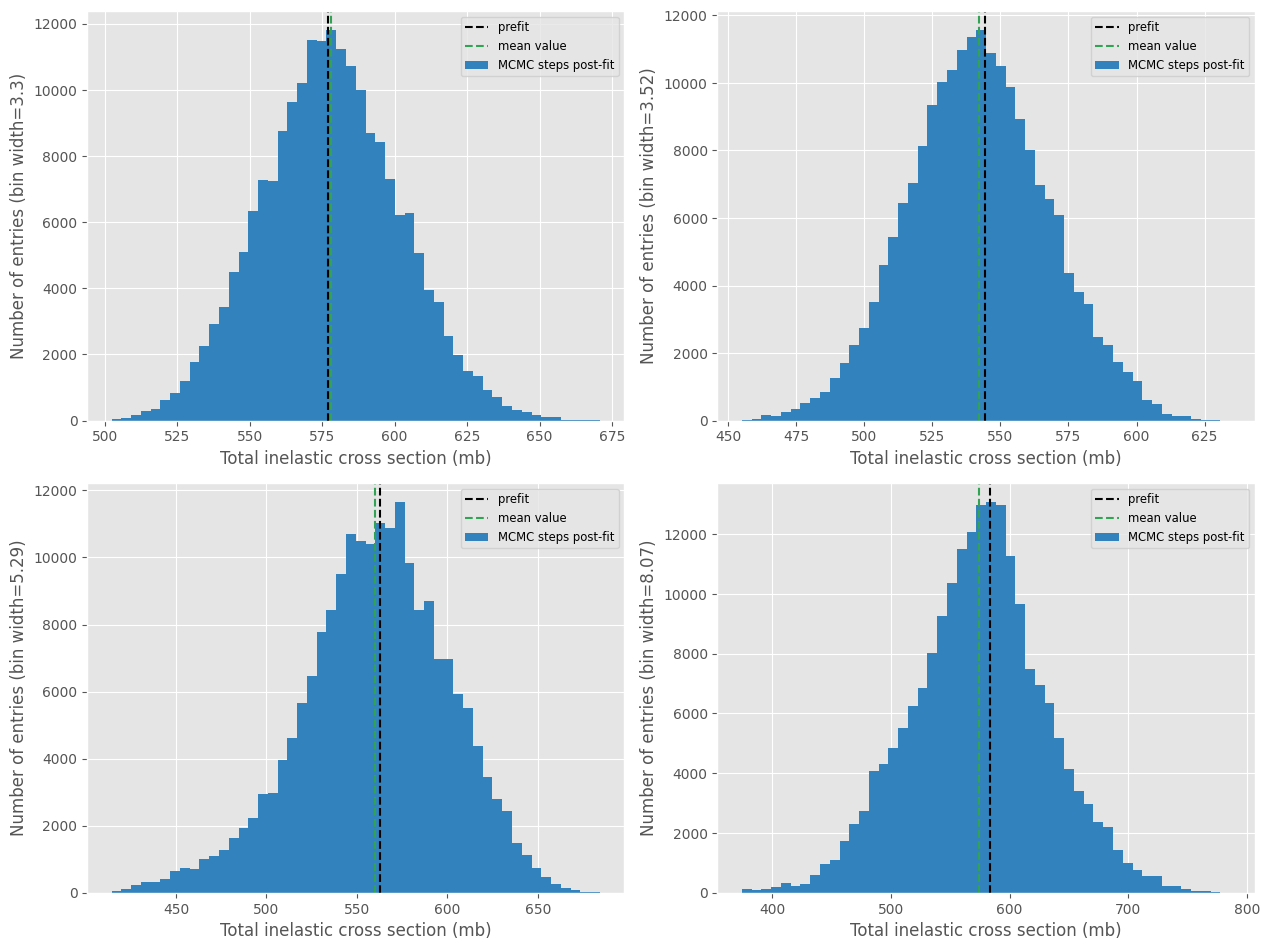

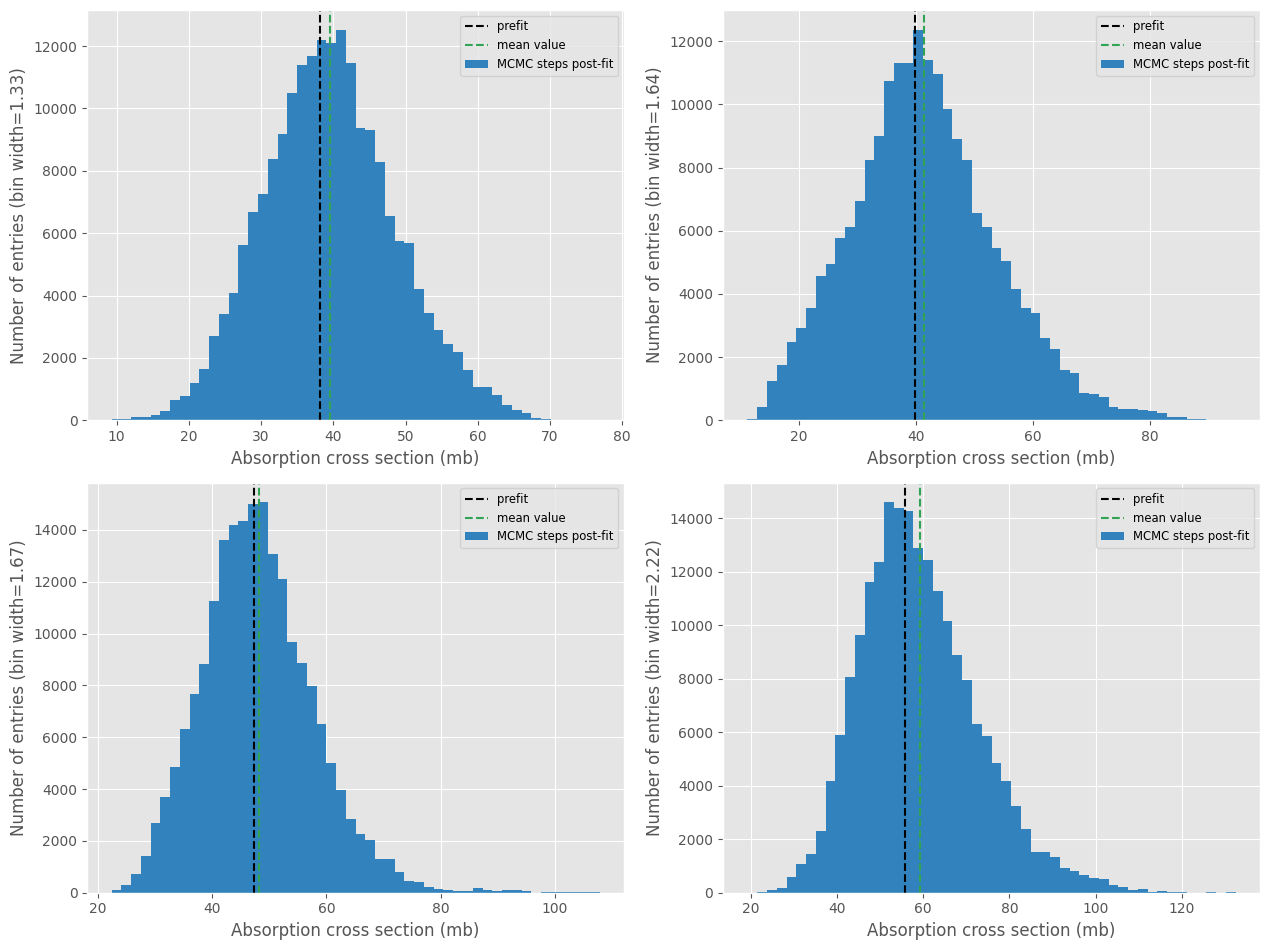

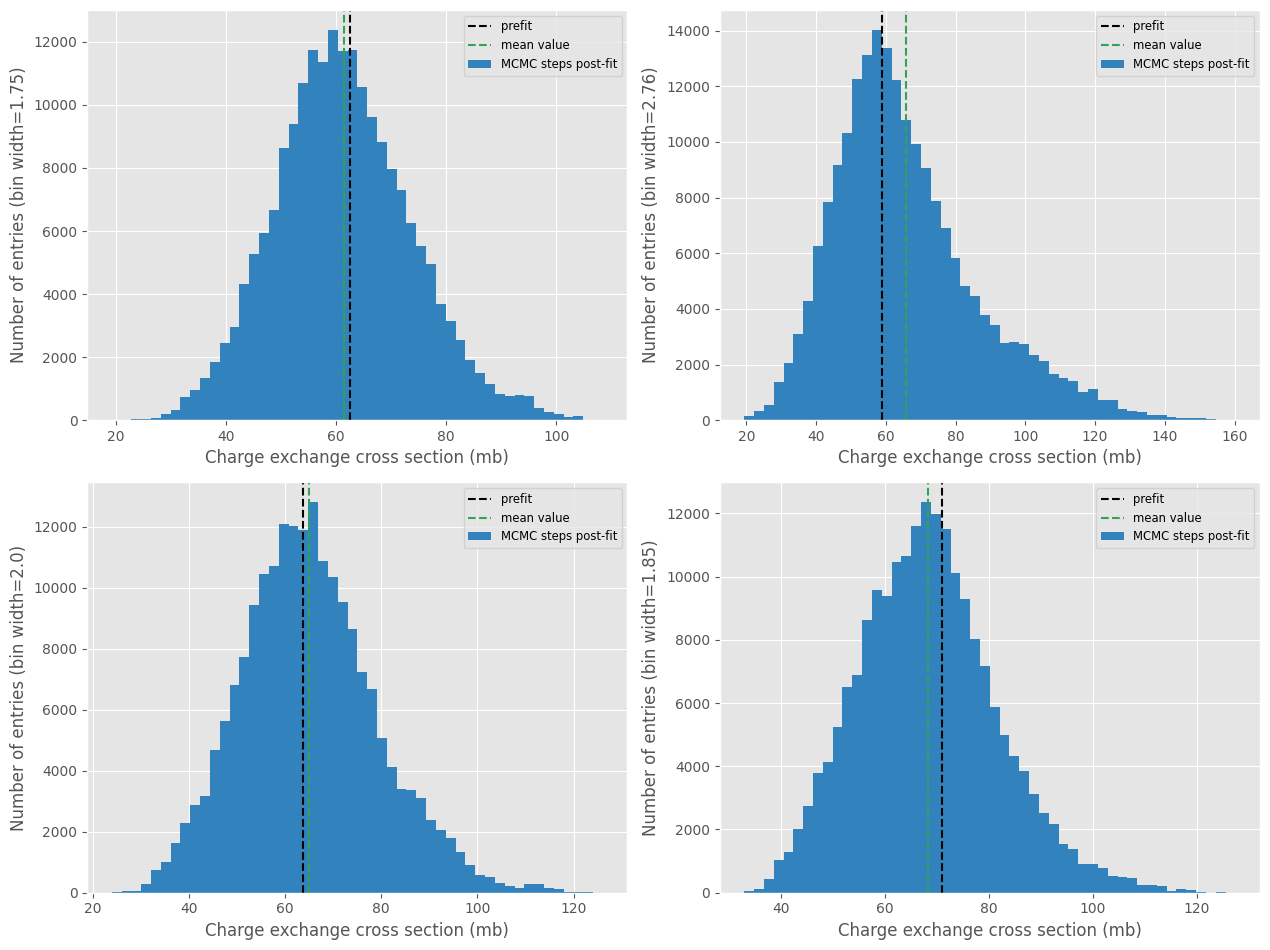

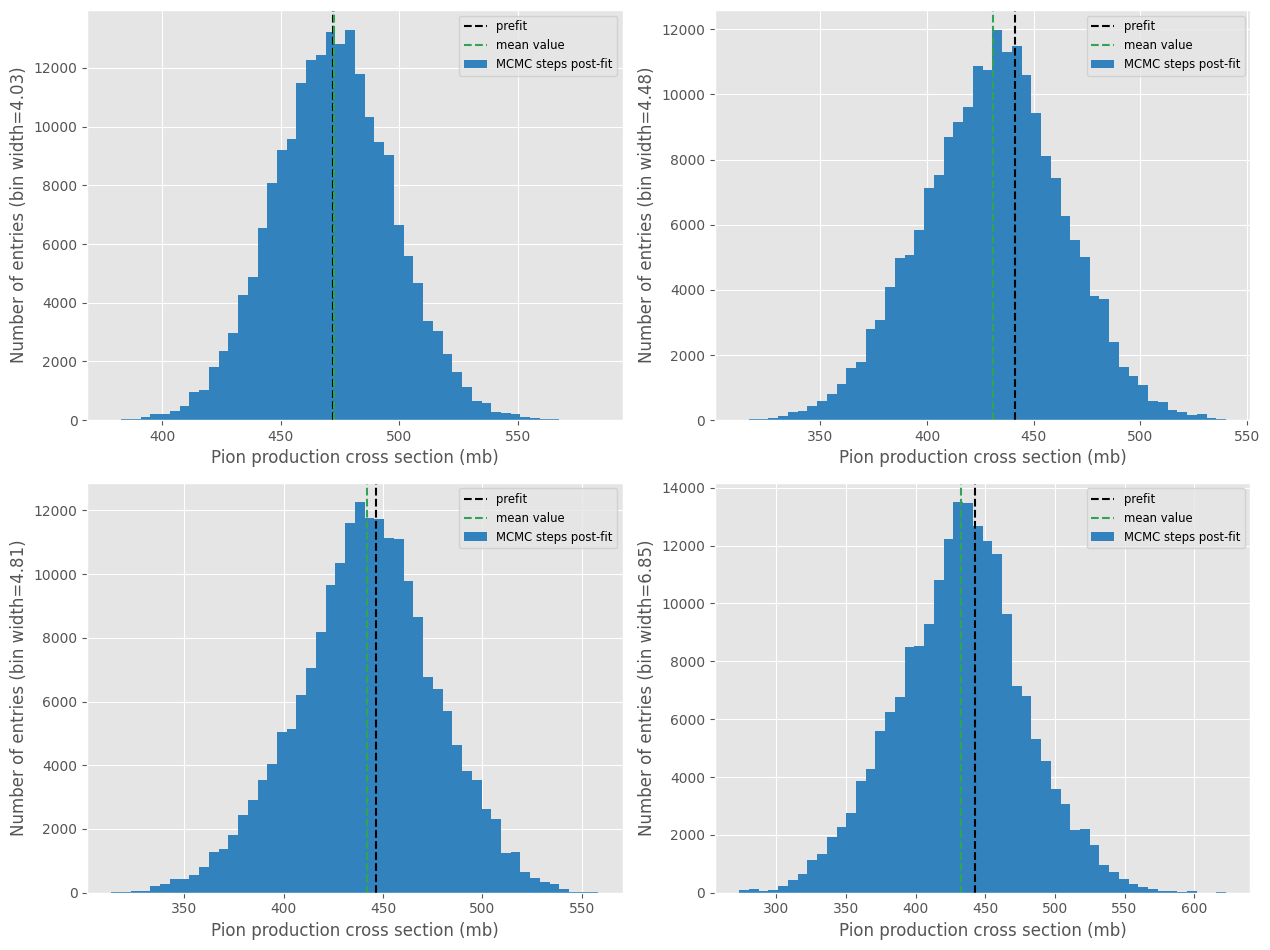

In [47]:
for k, v in postfit_cross_sections.items():
    PlotCrossSectionSteps(v, k, prefit_cross_sections[k])

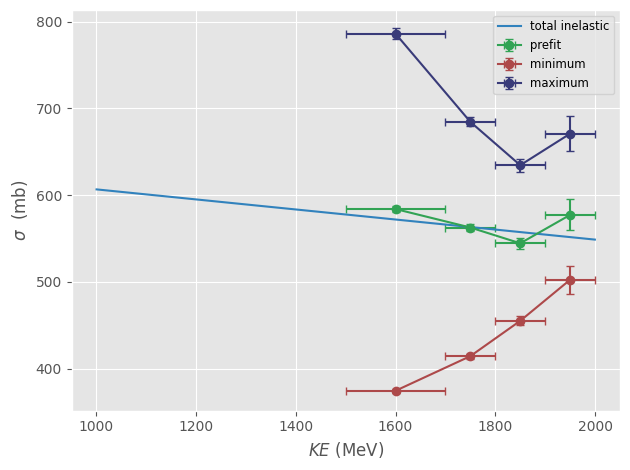

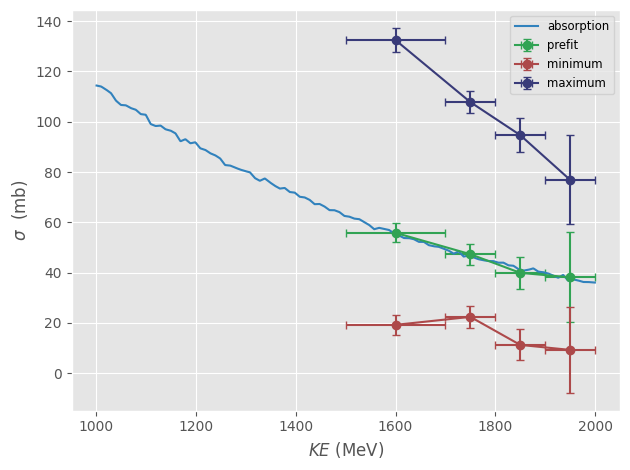

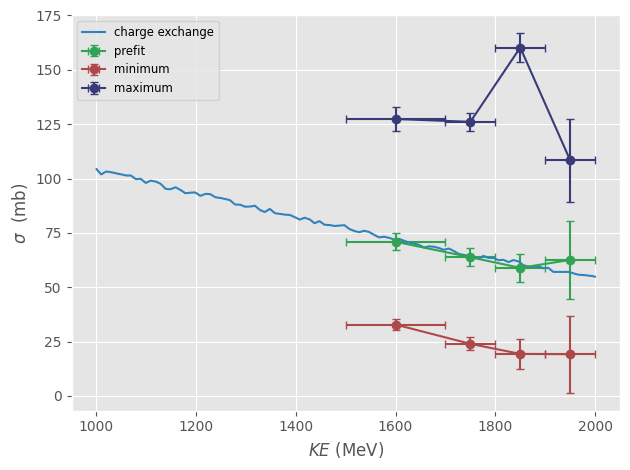

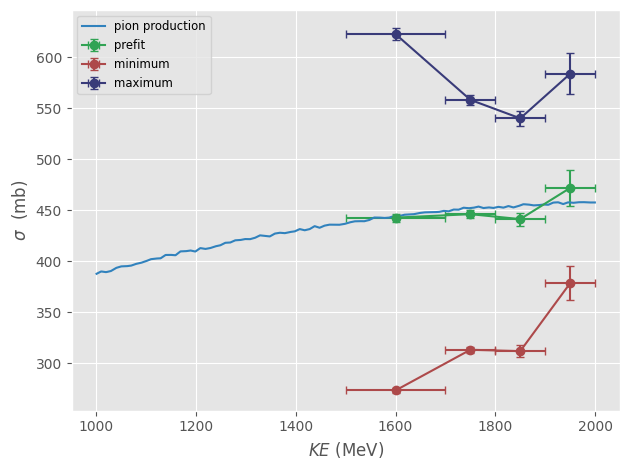

In [48]:
for k, v in postfit_cross_sections.items():
    PlotCrossSectionPosteriorRange(
    v,
    prefit_cross_sections[k],
    k,
    args.energy_slices,
    )
    book.Save()

Means and confidence intervals

In [23]:
book = Plots.PlotBook("xs_extract_ff_min_fv", True, None)

pdf xs_extract_ff_min_fv.pdf has been opened


In [49]:
cl = 0.68

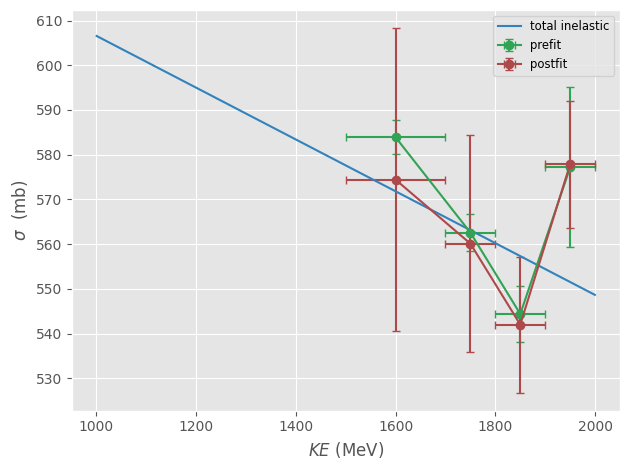

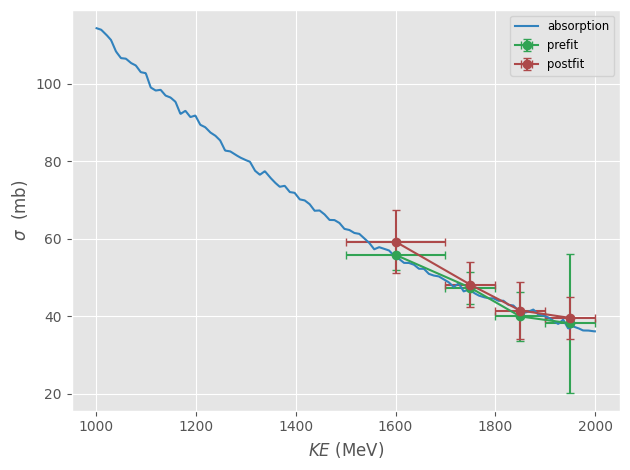

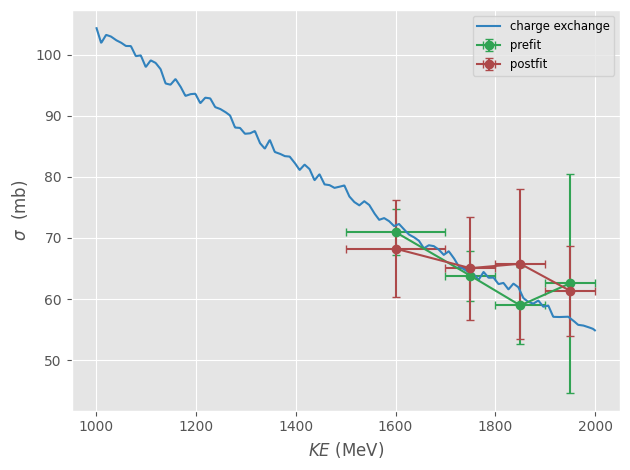

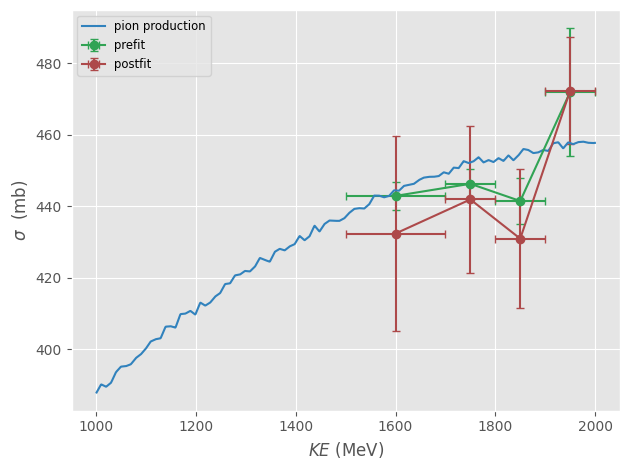

In [50]:
for k, v in postfit_cross_sections.items():
    PlotCrossSectionCL(v, prefit_cross_sections[k], k, args.energy_slices, cl)
    book.Save()

In [34]:
book.close()

pdf xs_extract.pdf has been closed
